## <font color= 'green'  align="center"> **MODELISATION DE L'ABSENSE DE POURBOIRE CHEZ LES CHAUFFEURS DE TAXI DE NEW YORK** </font>

![Imgur](https://media.lematin.ch/4/image/2023/11/10/51338278-59cd-4559-af66-8efbac423112.jpeg?auto=format%2Ccompress%2Cenhance&fit=max&w=1200&h=1200&rect=0%2C0%2C1024%2C683&s=7864704c0ca9395afa830274aeb70f2e)




# Contexte
Le projet porte sur la modélisation de la **générosité des clients** des taxis new-yorkais à partir de données de trajets.  
Il sera question pour nous dans ce projet de construire un modèle capable de prédire si un client **est_généreux** ou non, en se basant sur des variables telles que la durée du trajet, la distance, ou encore l’heure de la course...

Il aurait pu être question  pour nous de prédire si un client laissera un pourboire ou non, mais étant donné la problématique y relative, on se contentera de classifier un client de généreux ou non à partir de ses données

---

## Objectif
Prédire si un client sera classé **est_généreux** (donnera un pourboire supérieur ou égale à 20% du montant de la course) ou non, à partir des données de trajets de taxi à New York.

---

## Structure du Projet

### I. Chargement du Dataset

- Importation des bibliothèques nécessaires 
- Importation et fusion des deux parties du jeu de données 
- Création de la **target** binaire (ex: `Generous = tip_amount > 20%Total_amount`)

---

### II. Séparation du Dataset
- Séparation en deux sous-ensembles :
  - `Train set`
  - `Test set`
- (Utilisation de `train_test_split` de `sklearn`)

---

### III. Analyse exploratoire (EDA)
- Data understanding
- types de données
- Visualisation des distributions des variables:
  * Numériques
  * Catégorielles
- Analyse des dOutliers
- Analyse bivariée entre la target et les autres features
- Visualisation de la correlatione entre les variables numériques

---

### IV. Prétraitement
- Nettoyage des données (valeurs manquantes, types, outliers)
- Feature Engineering :
  - Création de variables à partir de la date/heure
- Encodage des variables catégorielles
- Standardisation / Normalisation si nécessaire

---

### V. Sélection et évaluation des modèles (Validation croisée)
- Mise en place d'une **Grid Search** avec **Validation Croisée**
- Entraînement et comparaison de plusieurs modèles :
  - KNN
  - Random Forest
  - Gradient Boosting
  - etc.
- Sélection des meilleurs hyperparamètres

---

### VI. Ré-entraînement final du modèle
- Entraînement sur **tout le Train Set** avec les meilleurs hyperparamètres

---

### VII. Évaluation sur le Test Set
- Prédictions finales
- Mesures de performance :
  - Accuracy, Precision, Recall, F1-Score
  - Matrice de confusion
  - ROC-AUC

---

### VIII. Conclusion & pistes d'amélioration
- Interprétation des résultats
- Analyse des erreurs
- Possibilités d'amélioration (plus de données, autres features, tuning...)



# <font color='brown'> I. CHARGEMENT DU DATASET </font>

In [40]:
# Manipulation de données
import pandas as pd
import numpy as np
import copy

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Prétraitement
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


# Modèles
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Évaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Pour le feature engineering (extraction de date, heure, etc.)
from datetime import datetime

In [42]:
## **Chargement et fusion des deux parties du dataset**
d1=pd.read_csv('2017_Yellow_Taxi_Trip_Data.csv')
d2=pd.read_csv('nyc_preds_means.csv')

data=pd.concat([d1,d2], axis=1)
data=pd.DataFrame(data)
data

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,mean_duration,mean_distance,predicted_fare
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,...,13.0,0.0,0.5,2.76,0.00,0.3,16.56,22.847222,3.521667,16.434245
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,...,16.0,0.0,0.5,4.00,0.00,0.3,20.80,24.470370,3.108889,16.052218
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,...,6.5,0.0,0.5,1.45,0.00,0.3,8.75,7.250000,0.881429,7.053706
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,...,20.5,0.0,0.5,6.39,0.00,0.3,27.69,30.250000,3.700000,18.731650
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,...,16.5,0.5,0.5,0.00,0.00,0.3,17.80,14.616667,4.435000,15.845642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22694,14873857,2,02/24/2017 5:37:23 PM,02/24/2017 5:40:39 PM,3,0.61,1,N,48,186,...,4.0,1.0,0.5,0.00,0.00,0.3,5.80,8.594643,1.098214,7.799138
22695,66632549,2,08/06/2017 4:43:59 PM,08/06/2017 5:24:47 PM,1,16.71,2,N,132,164,...,52.0,0.0,0.5,14.64,5.76,0.3,73.20,59.560417,18.757500,52.000000
22696,74239933,2,09/04/2017 2:54:14 PM,09/04/2017 2:58:22 PM,1,0.42,1,N,107,234,...,4.5,0.0,0.5,0.00,0.00,0.3,5.30,6.609091,0.684242,6.130896
22697,60217333,2,07/15/2017 12:56:30 PM,07/15/2017 1:08:26 PM,1,2.36,1,N,68,144,...,10.5,0.0,0.5,1.70,0.00,0.3,13.00,16.650000,2.077500,11.707049


In [43]:
#Création d'une copy du jeu de données
df=copy.deepcopy(data)

#Traduction de ses colonnes en français
# Dictionnaire de traduction 
column_translation = {
    "Unnamed: 0": "ID",
    "VendorID": "ID_ven",
    "tpep_pickup_datetime": "dt_départ",
    "tpep_dropoff_datetime": "dt_arrivée",
    "passenger_count": "nb_pass",
    "trip_distance": "dist_trajet",
    "RatecodeID": "code_tarif",
    "store_and_fwd_flag": "données_différé",
    "PULocationID": "ID_dep",
    "DOLocationID": "ID_arr",
    "payment_type": "type_paie",
    "fare_amount": "montant_course",
    "extra": "supplément",
    "mta_tax": "taxe_mta",
    "tip_amount": "pourboire",
    "tolls_amount": "péages",
    "improvement_surcharge": "suppl_amélioration",
    "total_amount": "montant_total",
    "mean_duration": "duree_moy",
    "mean_distance": "dist_moy",
    "predicted_fare": "tarif_prédit"
}

# Application du renommage
df.rename(columns=column_translation, inplace=True)

#Vérifie le résultat
print(df.columns)

Index(['ID', 'ID_ven', 'dt_départ', 'dt_arrivée', 'nb_pass', 'dist_trajet',
       'code_tarif', 'données_différé', 'ID_dep', 'ID_arr', 'type_paie',
       'montant_course', 'supplément', 'taxe_mta', 'pourboire', 'péages',
       'suppl_amélioration', 'montant_total', 'duree_moy', 'dist_moy',
       'tarif_prédit'],
      dtype='object')


In [46]:
# Création de la colonne 'client_genereux' qui est notre target
df['client_genereux'] = (df['pourboire'] >= 0.2 * df['montant_total']).astype(int)

# Créer le ratio pourboire / montant_total
df['ratio_tip/amount'] = df['pourboire'] / df['montant_total']

# Suppression des colonnes originales 'pourboire' et 'montant_total' pour éviter le "trucage"
df= df.drop(columns=['pourboire', 'montant_total'])

# Vérifier le résultat
df.head()

,ID,ID_ven,dt_départ,dt_arrivée,nb_pass,dist_trajet,code_tarif,données_différé,ID_dep,ID_arr,...,montant_course,supplément,taxe_mta,péages,suppl_amélioration,duree_moy,dist_moy,tarif_prédit,client_genereux,ratio_tip/amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,...,13.0,0.0,0.5,0.0,0.3,22.847222,3.521667,16.434245,0,0.166667
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,...,16.0,0.0,0.5,0.0,0.3,24.470370,3.108889,16.052218,0,0.192308
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,...,6.5,0.0,0.5,0.0,0.3,7.250000,0.881429,7.053706,0,0.165714
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,...,20.5,0.0,0.5,0.0,0.3,30.250000,3.700000,18.731650,1,0.230769
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,...,16.5,0.5,0.5,0.0,0.3,14.616667,4.435000,15.845642,0,0.000000


# <font color="brown"> II. SEPARATION DU DATASET </font>

In [49]:
# Définir X (features) et y (target)
X = df.drop(columns=['client_genereux'])
y = df['client_genereux']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% test, 80% train
    random_state=42,     # pour reproductibilité
    stratify=y           # garde la même proportion de classes dans y car ma target est déséquilibrée
)

# <font color='brown'>III. ANALYSE EXPLORATOIRE DE DONNEES (EDA) </font>

In [52]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18159 entries, 3996 to 6403
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  18159 non-null  int64  
 1   ID_ven              18159 non-null  int64  
 2   dt_départ           18159 non-null  object 
 3   dt_arrivée          18159 non-null  object 
 4   nb_pass             18159 non-null  int64  
 5   dist_trajet         18159 non-null  float64
 6   code_tarif          18159 non-null  int64  
 7   données_différé     18159 non-null  object 
 8   ID_dep              18159 non-null  int64  
 9   ID_arr              18159 non-null  int64  
 10  type_paie           18159 non-null  int64  
 11  montant_course      18159 non-null  float64
 12  supplément          18159 non-null  float64
 13  taxe_mta            18159 non-null  float64
 14  péages              18159 non-null  float64
 15  suppl_amélioration  18159 non-null  float64
 16  duree_m

In [54]:
X_train.describe()

,ID,ID_ven,nb_pass,dist_trajet,code_tarif,ID_dep,ID_arr,type_paie,montant_course,supplément,taxe_mta,péages,suppl_amélioration,duree_moy,dist_moy,tarif_prédit,ratio_tip/amount
count,1.815900e+04,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18157.000000
mean,5.702022e+07,1.555427,1.641004,2.920685,1.046093,162.510160,161.758357,1.339942,13.063972,0.332012,0.497247,0.312777,0.299537,14.445721,2.916524,12.983049,0.103645
std,3.270325e+07,0.496932,1.283365,3.674118,0.782576,66.777003,70.184640,0.498513,13.796419,0.463641,0.041227,1.405049,0.016353,10.108616,3.574283,9.741269,0.084903
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,-0.300000,0.000000,0.000000,2.934494,0.000000
25%,2.893806e+07,1.000000,1.000000,0.990000,1.000000,114.000000,113.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.300000,8.030952,1.006667,7.381905,0.000000
50%,5.681397e+07,2.000000,1.000000,1.600000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,0.000000,0.300000,11.556667,1.620000,9.560140,0.136986
75%,8.560409e+07,2.000000,2.000000,3.080000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,0.000000,0.300000,17.316667,3.114286,13.921530,0.166667
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,19.100000,0.300000,88.783333,33.920000,89.171050,0.786517


In [56]:
X_train.dtypes.value_counts()

float64    10
int64       7
object      3
Name: count, dtype: int64

In [58]:
# Valeurs manquantes
display(X_train.isnull().sum())

ID                    0
ID_ven                0
dt_départ             0
dt_arrivée            0
nb_pass               0
dist_trajet           0
code_tarif            0
données_différé       0
ID_dep                0
ID_arr                0
type_paie             0
montant_course        0
supplément            0
taxe_mta              0
péages                0
suppl_amélioration    0
duree_moy             0
dist_moy              0
tarif_prédit          0
ratio_tip/amount      2
dtype: int64

 **Interpretation**:
Le dataset est complet et ne contient aucune valeur manquante

In [61]:
#Séparation des variables catégorielles et des variables numériques
num_col=X_train.select_dtypes(include=['int', 'float']).columns
cat_col=X_train.select_dtypes(include=['object']).columns

print(f'Les colonnes numériques sont: {list(num_col)}')
print(f'Les colonnes catégorielles sont: {list(cat_col)}')

Les colonnes numériques sont: ['ID', 'ID_ven', 'nb_pass', 'dist_trajet', 'code_tarif', 'ID_dep', 'ID_arr', 'type_paie', 'montant_course', 'supplément', 'taxe_mta', 'péages', 'suppl_amélioration', 'duree_moy', 'dist_moy', 'tarif_prédit', 'ratio_tip/amount']
Les colonnes catégorielles sont: ['dt_départ', 'dt_arrivée', 'données_différé']


### 1) Analyse Multivariée

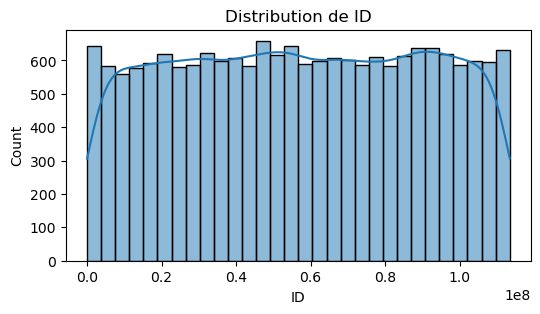

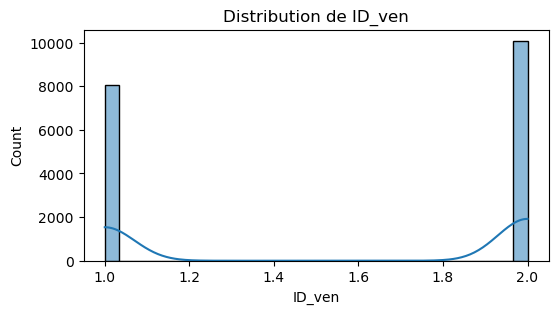

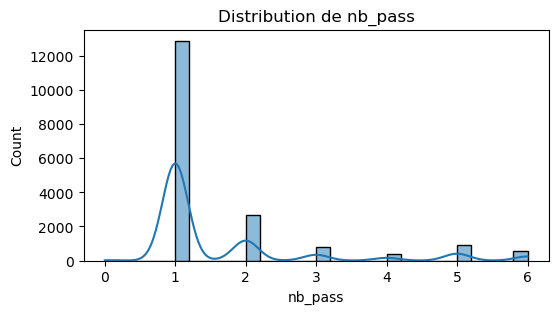

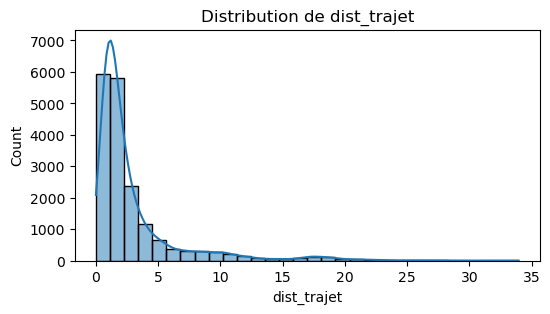

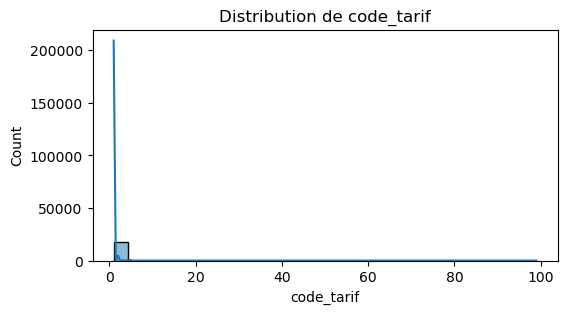

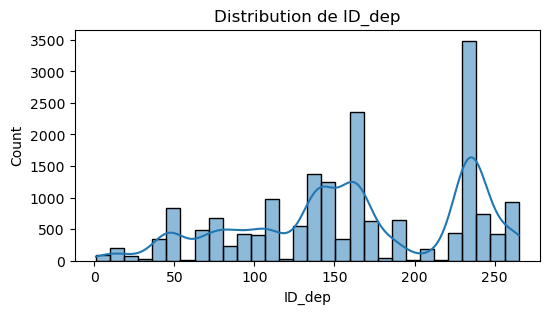

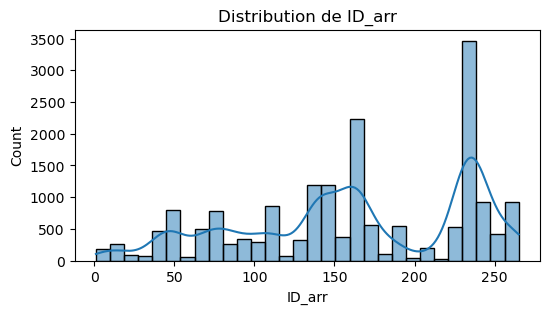

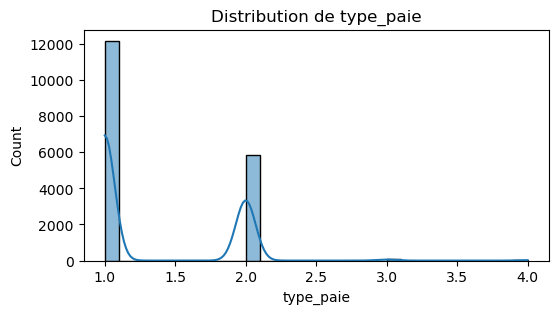

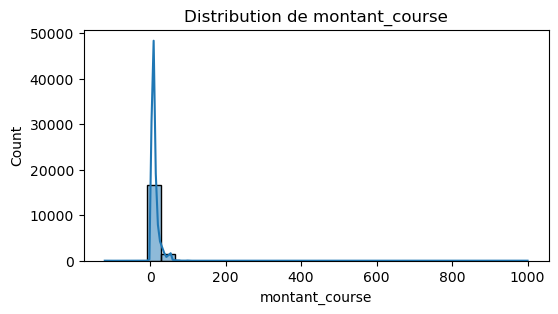

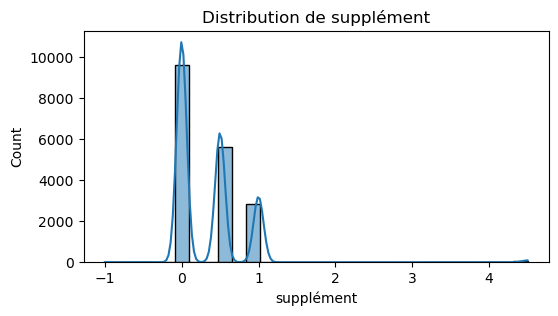

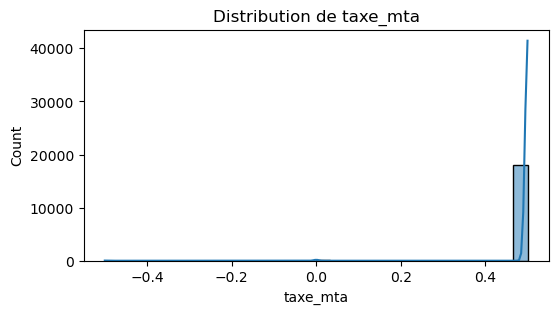

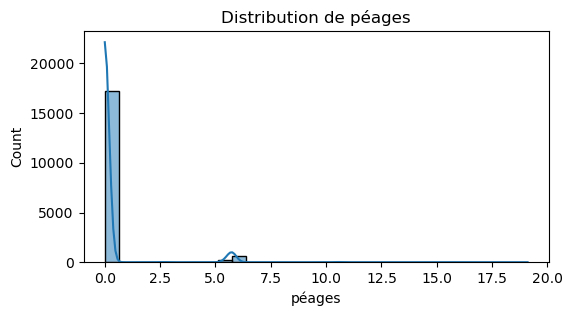

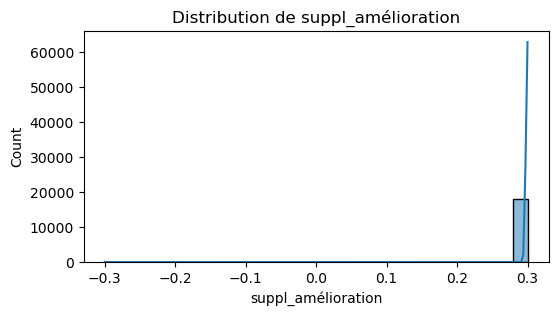

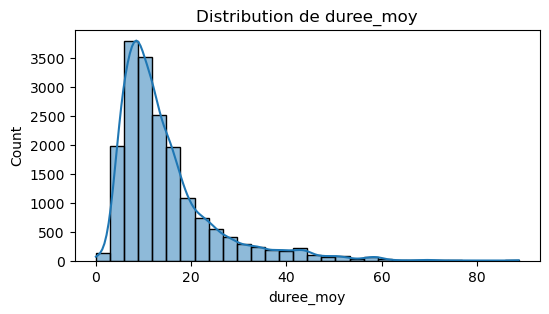

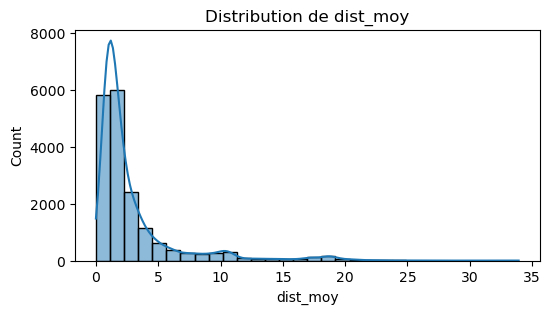

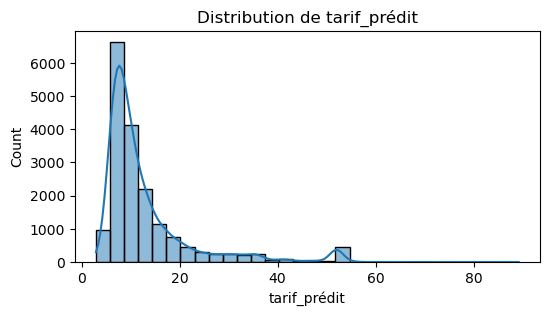

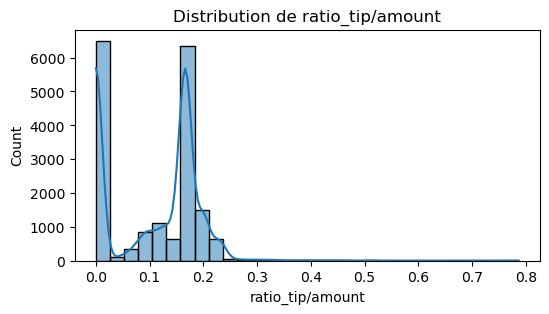

In [64]:
#Distributions des variables numériques:

for col in num_col:
    plt.figure(figsize=(6, 3))
    sns.histplot(X_train[col], kde=True, bins=30)
    plt.title(f'Distribution de {col}')
    plt.show()

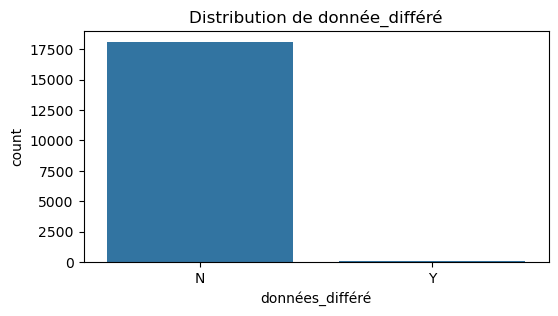

In [66]:

# Distribution des variables catégorielles:
plt.figure(figsize=(6, 3))

sns.countplot( data=X_train, x='données_différé') # Accès direct à la colonne via son nom

plt.title('Distribution de donnée_différé')
plt.show()  # Pour afficher le graphique


**Interpretation:** On ne peut visualiser que cette variables de type 'object' car les autres sont des datetime et c'est impossible de les visualiser

In [69]:

# Fonction pour détecter les outliers dans un DataFrame
def detect_outliers(df, columns):
    outliers_columns = []
    for col in columns:
        # Calcul de l'IQR pour chaque colonne
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Définition des bornes
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Détection des outliers : valeurs en dehors des bornes
        if ((df[col] < lower_bound) | (df[col] > upper_bound)).any():
            outliers_columns.append(col)

    return outliers_columns

# Appliquer la fonction sur les colonnes numériques
outliers_columns = detect_outliers(X_train, num_col)

# Afficher les colonnes contenant des outliers
print("Colonnes avec des outliers :")
print(outliers_columns)


Colonnes avec des outliers :
['nb_pass', 'dist_trajet', 'code_tarif', 'type_paie', 'montant_course', 'supplément', 'taxe_mta', 'péages', 'suppl_amélioration', 'duree_moy', 'dist_moy', 'tarif_prédit', 'ratio_tip/amount']


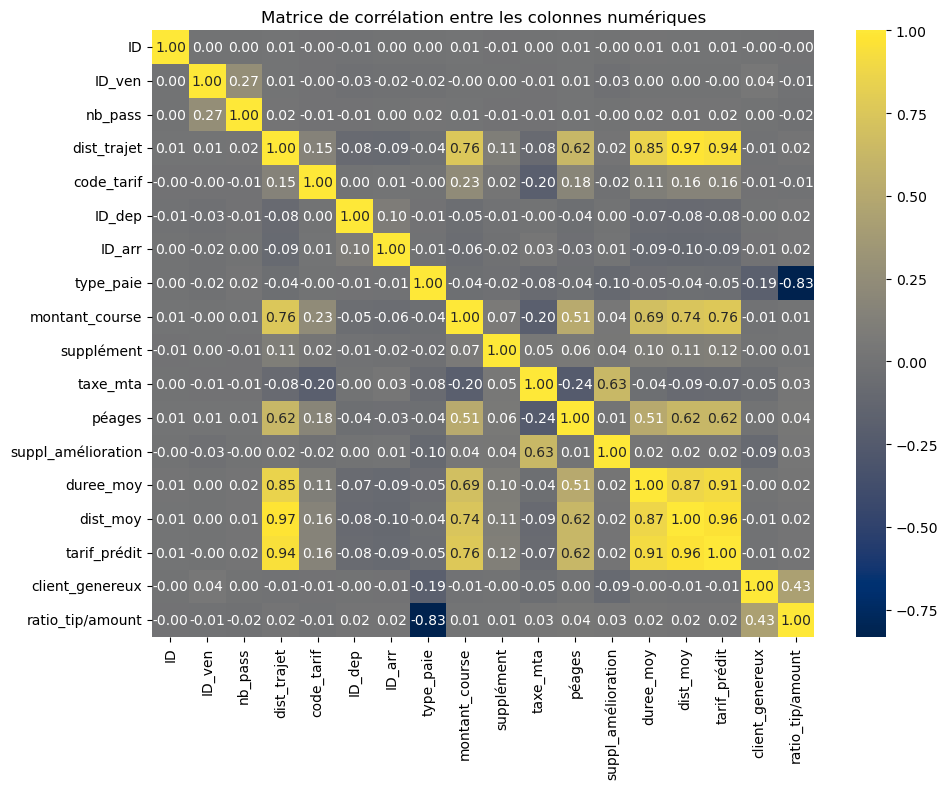

In [71]:
# Calculer la matrice de corrélation entre les colonnes numériques
corr_matrix = df.select_dtypes(include=['float', 'int']).corr()

# Visualisation de la matrice de corrélation avec une heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='cividis', fmt=".2f", )
plt.title("Matrice de corrélation entre les colonnes numériques")
plt.tight_layout()
plt.show()

### 2) Analyse Bivariée

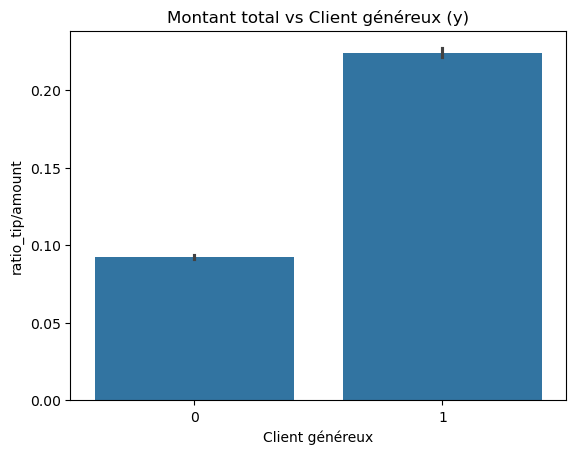

In [78]:
# Distribution de ratio_tip/amount selon y=Target
sns.barplot(x=y, y=X_train["ratio_tip/amount"])
plt.title("Montant total vs Client généreux (y)")
plt.xlabel("Client généreux")
plt.ylabel("ratio_tip/amount")
plt.show()


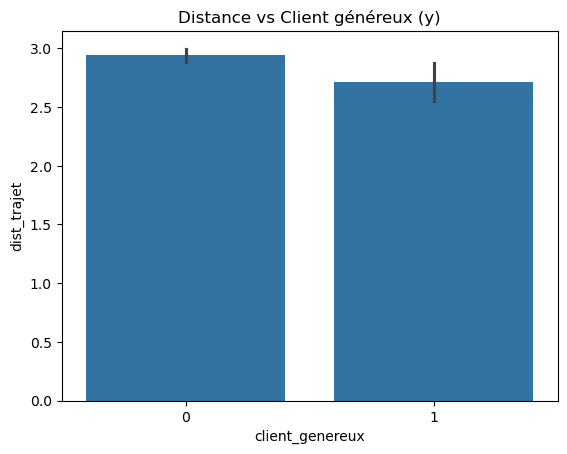

In [101]:
#Distribution de Distance_trajet selon y
sns.barplot(x=y, y=X_train["dist_trajet"])
plt.title("Distance vs Client généreux (y)")
plt.show()

**Interpretation:** Plus la distance est grande et moins les clients sont généreux

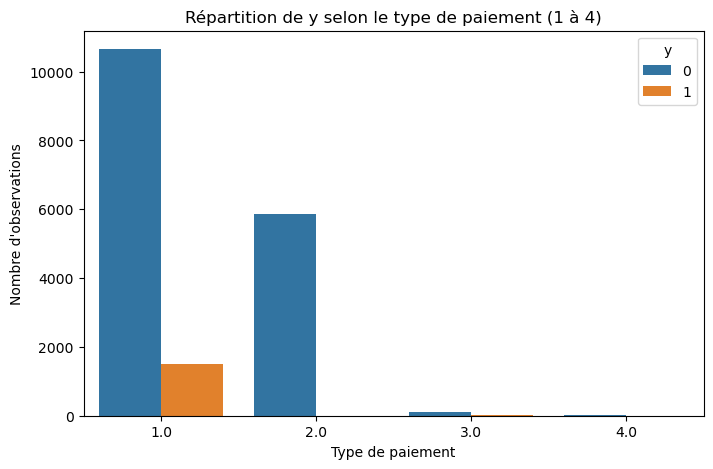

In [83]:
#Proportion de clients généreux selon le type de paie

plt.figure(figsize=(8, 5))
sns.countplot(x=X_train["type_paie"], hue=y)
plt.title("Répartition de y selon le type de paiement (1 à 4)")
plt.xlabel("Type de paiement")
plt.ylabel("Nombre d'observations")
plt.legend(title="y")


**Interpretation:** La majorité des observations pour y=0 et y=1 se trouvent dans les types de paiement 1 et 2, avec une forte dominance de y=0. Les types de paiement 3 et 4 ont très peu d'observations pour les deux catégories.



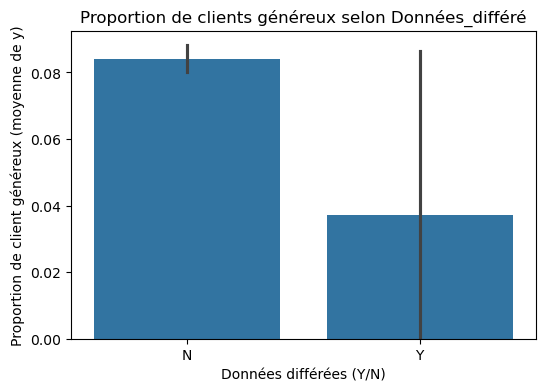

In [113]:
plt.figure(figsize=(6, 4))
sns.barplot(x=X_train["données_différé"], y=y)
plt.title("Proportion de clients généreux selon Données_différé")
plt.xlabel("Données différées (Y/N)")
plt.ylabel("Proportion de client généreux (moyenne de y)")
plt.show()

**Interpretation:** Les clients généreux sont proportionnellement plus nombreux lorsque les données ne sont pas différées ("N"). En revanche, la proportion diminue lorsque les données sont différées ("Y").



# <font color='brown'>IV. PREPROCESSING </font>